# Decision Trees

Can be used for solving both regression and classification problems.
It predicts an outcome by asking a sequence of if-then questions about the input features.


There are various algorithms for implementing Decision Trees. Such as :

CART,ID3. Sklearn uses CART under the hood which uses Gini Impurity.

Decision trees split themselves until the leaf node is reached i.e. we get a pure split. 

Decision Trees depends largely on feature selection. So in order to measure the degree of purity of the split we use -
         
         * Gini Impurity- max value is 0.5. and when it's 0.5 then it is most impure split.
         * Entropy - ranges from [0,1].

Higher the Entropy - poor that feature's split is. which occurs in case of complete impure split i.e. entropy becomes 1.


# Entropy vs Gini Impurity

Training speed is slower in entropy while faster computation in gini impurity.


Entropy produces more balanced node partitions while gini creates splits quickly.


Entropy is useful for structured datasets while gini is efficient for large and high dimensional datasets.

## Information Gain

IG is the measure that is used to decide which feature to split on. Higher the information Gain, that feature is taken.

## Pruning
 
Pruning is a techinique used in Decision Trees to remove parts of the tree that are unnecessary and in order to reduce overfitting and improve performance in unseen data. It can be done in two ways :  pre-pruning and post pruning.

## Common Pruning rules

1. Max Depth

2.min_samples_split- Node must contain at least N sample to be split.

3.min_samples_leaf-leaf must contain at lest N samples.

4. ma_leaf_nodes - Limit the total number of leaf nodes.

5. min_impurity_decrease-only split if impurity reduction exceeds threshold.

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [23]:
titanic=sns.load_dataset("titanic")
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [24]:
features=["embarked","sex","fare","embarked","age"]
target=["survived"]

In [25]:
titanic["age"] = titanic["age"].fillna(titanic["age"].median())
titanic["embarked"] = titanic["embarked"].fillna(titanic["embarked"].mode()[0])

In [26]:
titanic.isna().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [27]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

titanic["sex"]=le.fit_transform(titanic["sex"])
titanic["embarked"]=le.fit_transform(titanic["embarked"])

In [28]:
X=titanic[features]
y=titanic[target]


In [29]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [30]:
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier()
model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [31]:
from sklearn.metrics import accuracy_score

y_pred=model.predict(X_test)
acc=accuracy_score(y_test,y_pred)

print("Accuracy : ",acc)

Accuracy :  0.75


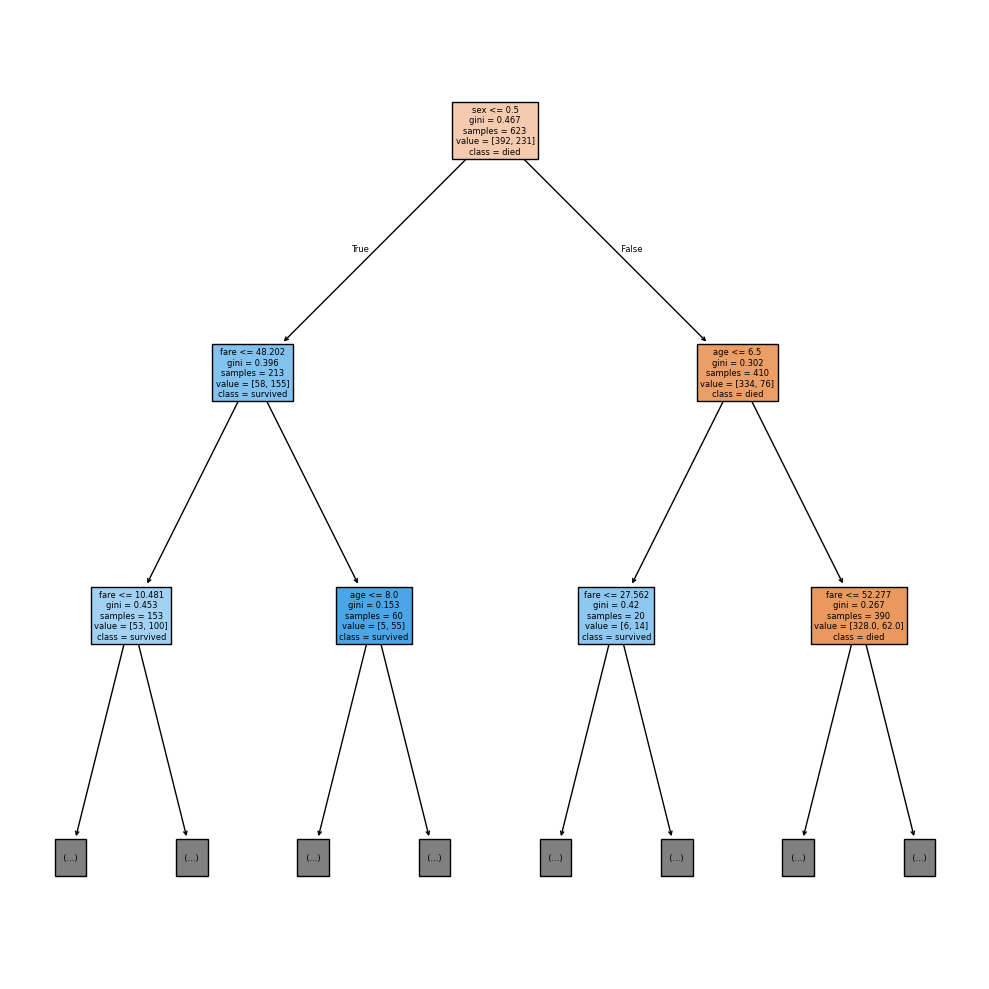

In [33]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["died","survived"],
    filled=True,
    max_depth=2
)
plt.tight_layout()
plt.show()